In [1]:
pip install transformers

   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   -------- ------------------------------- 2.4/10.6 MB 14.7 MB/s eta 0:00:01
   ------------------ --------------------- 5.0/10.6 MB 13.5 MB/s eta 0:00:01
   ---------------------------- ----------- 7.6/10.6 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------  10.5/10.6 MB 13.2 MB/s eta 0:00:01
   ---------------------------------------- 10.6/10.6 MB 12.9 MB/s  0:00:00
   ---------------------------------------- 0.0/663.6 kB ? eta -:--:--
   ---------------------------------------- 663.6/663.6 kB 17.8 MB/s  0:00:00
   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------------- ------------- 2.6/4.0 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 12.9 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 12.7 MB/s  0:00:00

   --- ---------------------

In [2]:
import os
os.chdir(r'd:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert')


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from transformers import DataCollatorWithPadding
from datasets import Dataset

#load data
df = pd.read_csv(r'd:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\lexicon_label.csv')

df.info()
df.head(5)

ModuleNotFoundError: No module named 'seaborn'

In [6]:
# Remove Duplikasi
df = df.dropna(subset=['normalisasi', 'Sentiment'])
# df = df[:1000]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   normalisasi  7646 non-null   object
 1   Score        7646 non-null   int64 
 2   Sentiment    7646 non-null   object
dtypes: int64(1), object(2)
memory usage: 179.3+ KB


In [7]:
# Encode label jika belum numerik
if df['Sentiment'].dtype == 'object':
    df['Sentiment'] = df['Sentiment'].astype('category').cat.codes

# Split data 80:10:10 (train:validation:test)
# Pertama split 80:20
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# Kemudian split 20% menjadi 10:10 (validation:test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Verifikasi proporsi
print(f"Train size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Train size: 6116 (80.0%)
Validation size: 765 (10.0%)
Test size: 765 (10.0%)


In [8]:
# Tokenizer IndoBERT
tokenizer = BertTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

def tokenize_function(example):
    return {
        **tokenizer(example["normalisasi"], truncation=True),
        'labels': example['Sentiment']
    }

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 765/765 [00:00<00:00, 5924.74 examples/s]


In [ ]:
# Load IndoBERT for classification
model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=df['Sentiment'].nunique())

# Training arguments dengan hyperparameter yang lebih optimal
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,  # Baik untuk BERT (bisa coba: 3e-5, 5e-5)
    per_device_train_batch_size=8,  # Naikkan jika memori cukup (8 -> 16)
    per_device_eval_batch_size=32,  # Naikkan untuk evaluasi lebih cepat
    num_train_epochs=10,  # Naikkan epochs, early stopping akan menghentikan jika perlu
    weight_decay=0.01,  # Baik untuk regularisasi
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=10,
    warmup_steps=500,  # Tambahkan warmup untuk stabilitas
    gradient_accumulation_steps=2,  # Tambahkan jika batch size kecil
    fp16=True,  # Aktifkan mixed precision jika GPU support
    save_total_limit=2,  # Batasi jumlah checkpoint yang disimpan
)

# Early stopping callback - berhenti jika metric tidak membaik setelah 3 epoch
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=3,  # Jumlah epoch tanpa improvement sebelum berhenti
    early_stopping_threshold=0.0  # Minimum improvement yang dianggap signifikan
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# Fungsi untuk menghitung metrik lebih lengkap
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Hitung accuracy
    accuracy = accuracy_score(labels, predictions)

    # Hitung precision, recall, f1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Inisialisasi Trainer dengan validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback],
)

In [11]:
# ===== TAMBAHKAN CLASS WEIGHTS =====
from sklearn.utils.class_weight import compute_class_weight

# 1. Hitung class weights dari training data
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['Sentiment']),
    y=train_df['Sentiment']
)

print("=" * 50)
print("CLASS WEIGHTS")
print("=" * 50)
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")
print("=" * 50)

# 2. Custom Trainer dengan Weighted Loss (UPDATED SIGNATURE)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Custom loss function dengan class weights

        Args:
            model: Model yang sedang di-training
            inputs: Dictionary berisi input data
            return_outputs: Boolean untuk return outputs atau tidak
            num_items_in_batch: Jumlah item dalam batch (parameter baru di Transformers >= 4.30)
        """
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Gunakan CrossEntropyLoss dengan class weights
        loss_fct = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights, dtype=torch.float).to(logits.device)
        )
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

# 3. Ganti Trainer biasa dengan WeightedTrainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback],
)

print("\n✓ Trainer dengan class weights berhasil diinisialisasi!")

CLASS WEIGHTS
Class 0: 0.5428
Class 1: 1.6710
Class 2: 1.7883

✓ Trainer dengan class weights berhasil diinisialisasi!


In [ ]:
# Train model
trainer.train()

d:\Data\Kuliah\Semester 7\Skripsi\tiktok-indobert\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
# 1. Evaluasi model pada test dataset
test_results = trainer.predict(test_dataset)
test_predictions = np.argmax(test_results.predictions, axis=1)
test_labels = test_results.label_ids

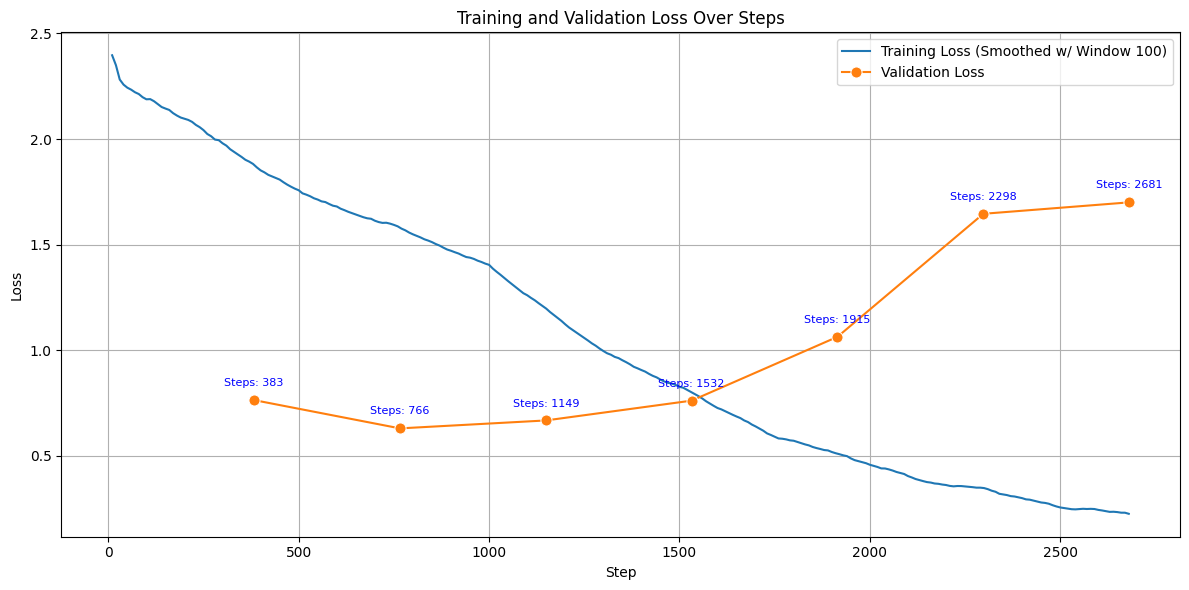

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# The 'trainer' object available here is the one from the last training run
# (the one without class weights, from cells OXqiMOFQycOt, FcVEiwhlykrN, ANOFcKeVyw2E)

# Extract logs from the trainer's state history
logs = trainer.state.log_history

# Filter for training and evaluation metrics
# Training loss logs have 'loss' but generally not 'eval_loss'
# Evaluation loss logs have 'eval_loss'
train_losses_data = []
eval_losses_data = []

for log in logs:
    if 'loss' in log and 'eval_loss' not in log:
        train_losses_data.append({'step': log['step'], 'loss': log['loss'], 'epoch': log['epoch']})
    elif 'eval_loss' in log:
        eval_losses_data.append({'step': log['step'], 'eval_loss': log['eval_loss'], 'epoch': log['epoch']})

train_log_df = pd.DataFrame(train_losses_data)
eval_log_df = pd.DataFrame(eval_losses_data)

# Apply rolling average to training loss for smoothing
window_size = 100  # Increased window size for more smoothing
if not train_log_df.empty:
    train_log_df['smoothed_loss'] = train_log_df['loss'].rolling(window=window_size, min_periods=1).mean()

# Plotting
plt.figure(figsize=(12, 6))

# Plot Smoothed Training Loss
if not train_log_df.empty:
    sns.lineplot(x='step', y='smoothed_loss', data=train_log_df, label=f'Training Loss (Smoothed w/ Window {window_size})')

# Plot Validation Loss with circular markers and annotations for step count
if not eval_log_df.empty:
    sns.lineplot(x='step', y='eval_loss', data=eval_log_df, label='Validation Loss', marker='o', markersize=8)
    # Add step count annotation at each validation point
    for i, row in eval_log_df.iterrows():
        plt.annotate(
            f"Steps: {int(row['step'])}",  # Display only step count
            (row['step'], row['eval_loss']),
            textcoords="offset points",
            xytext=(0,10), # distance from text to points (x,y)
            ha='center',   # horizontal alignment
            fontsize=8,
            color='blue'
        )

plt.title('Training and Validation Loss Over Steps')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 2. Hitung metrik evaluasi
print("=" * 50)
print("HASIL EVALUASI PADA TEST SET")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(test_labels, test_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=['Negatif', 'Netral', 'Positif']))

HASIL EVALUASI PADA TEST SET

Accuracy: 0.8144

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.92      0.89      0.91       465
      Netral       0.57      0.66      0.61       157
     Positif       0.80      0.72      0.76       143

    accuracy                           0.81       765
   macro avg       0.76      0.76      0.76       765
weighted avg       0.82      0.81      0.82       765



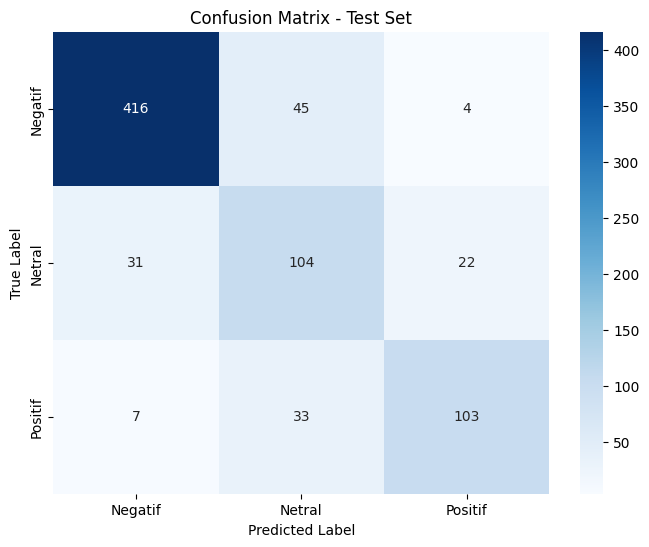

In [ ]:
# 3. Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Tidak Memakai Class Weight

In [ ]:
from transformers import EarlyStoppingCallback

model = BertForSequenceClassification.from_pretrained("indobenchmark/indobert-base-p1", num_labels=df['Sentiment'].nunique())

# Training arguments dengan learning rate adaptif
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
    # early_stopping_patience=3, # Removed: Handled by EarlyStoppingCallback
    # greater_is_better=True # Removed: Handled by EarlyStoppingCallback
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Fungsi untuk menghitung metrik lebih lengkap
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Hitung accuracy
    accuracy = accuracy_score(labels, predictions)

    # Hitung precision, recall, f1-score
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Inisialisasi Trainer dengan validation dataset
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3, early_stopping_threshold=0.001)] # Added EarlyStoppingCallback
)

In [ ]:
# Train model
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.705777,0.544335,0.785621,0.771418,0.785621,0.775247
2,0.398072,0.507452,0.820915,0.823892,0.820915,0.821960
3,0.267497,0.660983,0.823529,0.827188,0.823529,0.825220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# 1. Evaluasi model pada test dataset
test_results = trainer.predict(test_dataset)
test_predictions = np.argmax(test_results.predictions, axis=1)
test_labels = test_results.label_ids

In [ ]:
# 2. Hitung metrik evaluasi
print("=" * 50)
print("HASIL EVALUASI PADA TEST SET")
print("=" * 50)
print(f"\nAccuracy: {accuracy_score(test_labels, test_predictions):.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, test_predictions, target_names=['Negatif', 'Netral', 'Positif']))

In [ ]:
# 3. Confusion Matrix
cm = confusion_matrix(test_labels, test_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif', 'Netral', 'Positif'],
            yticklabels=['Negatif', 'Netral', 'Positif'])
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()